# Machine Learning Pipeline for Diabetes Prediction 

## Part 0 - Import Libraries and Set Up Folders

In [1]:
import os
import sys
import shutil
import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

PLOTS_DIR = "/kaggle/working/plots" if os.path.exists("/kaggle/working") else "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
RANDOM_STATE = 42
TARGET = "Outcome"



## Part 1 - Dataset Preparation

The assignment asks to:
1. Download the `diabetes.csv` dataset
2. Load it using pandas
3. Show shape, data types, and first rows

In [2]:
DATASET_URL = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
KAGGLE_DATASET_DIR = "/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database"
LOCAL_FILE = "diabetes.csv"

kaggle_candidates = []
if os.path.exists(KAGGLE_DATASET_DIR):
    kaggle_candidates = sorted(glob.glob(os.path.join(KAGGLE_DATASET_DIR, "*.csv")))

if kaggle_candidates:
    DATA_SOURCE_USED = kaggle_candidates[0]
    df = pd.read_csv(DATA_SOURCE_USED)
    print(f"Loaded Kaggle dataset file: {DATA_SOURCE_USED}")
elif os.path.exists(LOCAL_FILE):
    DATA_SOURCE_USED = LOCAL_FILE
    df = pd.read_csv(DATA_SOURCE_USED)
    print(f"Loaded local file: {DATA_SOURCE_USED}")
else:
    DATA_SOURCE_USED = DATASET_URL
    df = pd.read_csv(DATA_SOURCE_USED)
    df.to_csv(LOCAL_FILE, index=False)
    print(f"Downloaded dataset from: {DATASET_URL}")
    print(f"Saved as: {LOCAL_FILE}")

print("\nDataset loaded successfully.")



Loaded Kaggle dataset file: /kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv

Dataset loaded successfully.


In [3]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

Dataset Shape: (768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Part 2 - Exploratory Data Analysis (EDA)

Required EDA tasks:
- Summary statistics
- Missing values
- Class distribution
- Correlation heatmap

In [4]:
print("Summary Statistics:")
display(df.describe())

print("\nMissing Values (actual NaN values):")
display(df.isnull().sum().to_frame("Missing Values"))

# In this dataset, some medical variables should not realistically be 0.
# These zero values are often treated as invalid or missing in practice.
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

invalid_zero_counts = (df[invalid_zero_cols] == 0).sum().to_frame("Zero Count")
print("\nPotentially Invalid Zero Values:")
display(invalid_zero_counts)

Summary Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Missing Values (actual NaN values):


,Missing Values
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Potentially Invalid Zero Values:


,Zero Count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


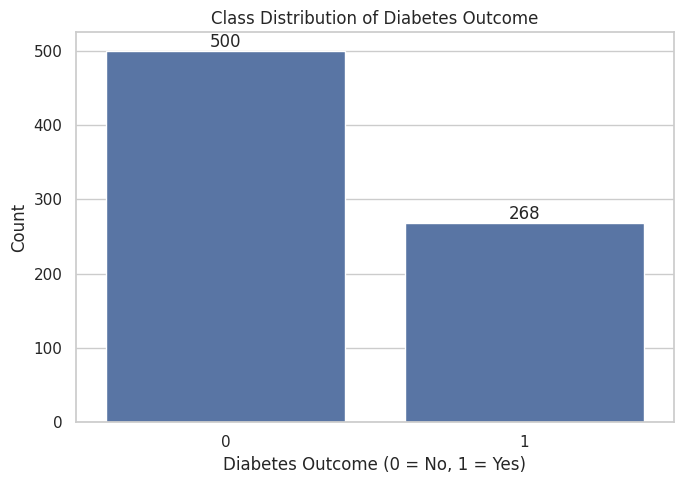

Saved plot: /kaggle/working/plots/class_distribution.png


In [5]:
# Class distribution of the target variable
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=TARGET, data=df)
plt.title("Class Distribution of Diabetes Outcome")
plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

class_plot_path = os.path.join(PLOTS_DIR, "class_distribution.png")
plt.tight_layout()
plt.savefig(class_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot: {class_plot_path}")

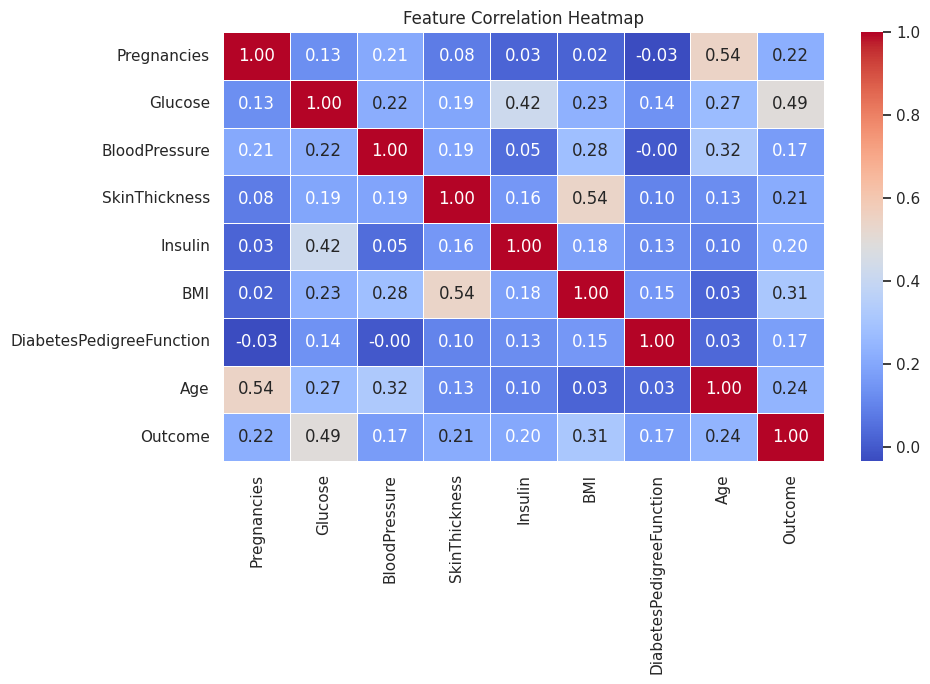

Saved plot: /kaggle/working/plots/correlation_heatmap.png


In [6]:
# Create an EDA-friendly cleaned copy for plotting/correlation
eda_df = df.copy()
eda_df[invalid_zero_cols] = eda_df[invalid_zero_cols].replace(0, np.nan)

# Fill only for EDA correlation/visualization
eda_df[invalid_zero_cols] = eda_df[invalid_zero_cols].fillna(
    eda_df[invalid_zero_cols].median()
)

corr = eda_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
heatmap_path = os.path.join(PLOTS_DIR, "correlation_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot: {heatmap_path}")

## Part 8 - Additional Visualizations

The assignment asks for at least two visualizations.  
This notebook creates multiple visuals:
- Feature correlation heatmap
- Glucose distribution by diabetes outcome
- Age distribution
- BMI distribution

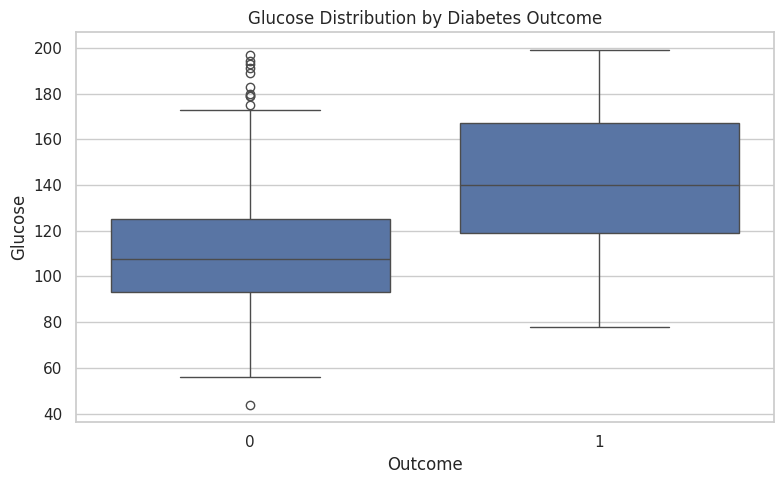

Saved plot: /kaggle/working/plots/glucose_distribution_by_outcome.png


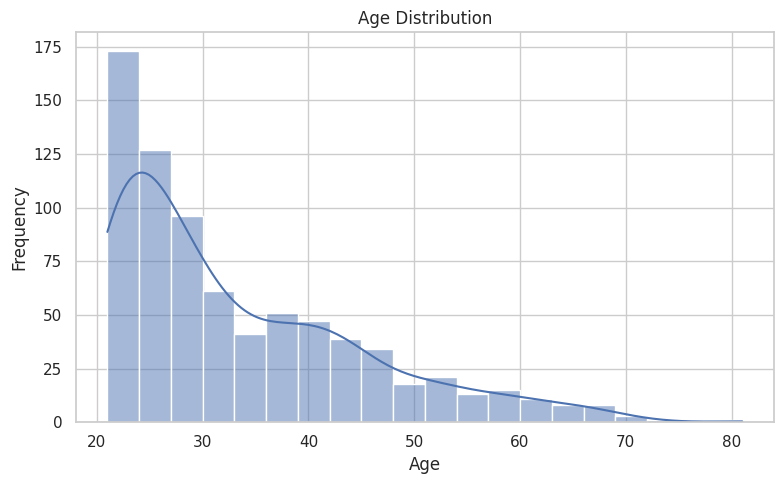

Saved plot: /kaggle/working/plots/age_distribution.png


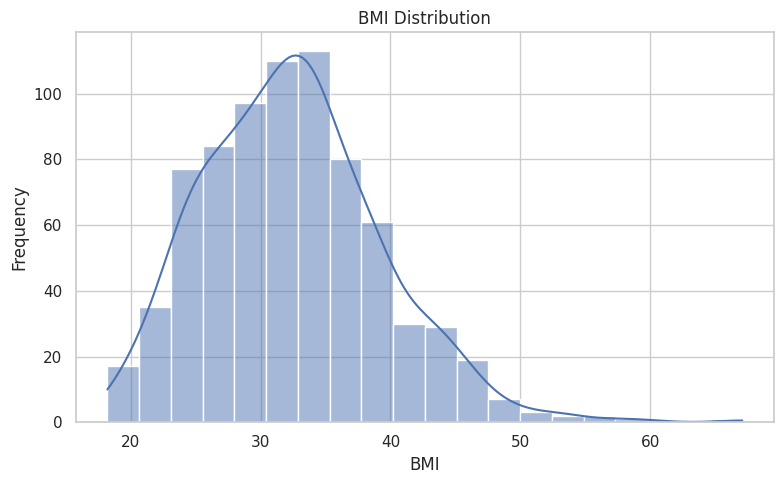

Saved plot: /kaggle/working/plots/bmi_distribution.png


In [7]:
# Glucose distribution by outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x=TARGET, y="Glucose", data=eda_df)
plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
glucose_plot_path = os.path.join(PLOTS_DIR, "glucose_distribution_by_outcome.png")
plt.tight_layout()
plt.savefig(glucose_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot: {glucose_plot_path}")

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(eda_df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
age_plot_path = os.path.join(PLOTS_DIR, "age_distribution.png")
plt.tight_layout()
plt.savefig(age_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot: {age_plot_path}")

# BMI distribution
plt.figure(figsize=(8, 5))
sns.histplot(eda_df["BMI"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
bmi_plot_path = os.path.join(PLOTS_DIR, "bmi_distribution.png")
plt.tight_layout()
plt.savefig(bmi_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot: {bmi_plot_path}")

## Part 3 - Data Preprocessing

We now:
- Separate features (`X`) and target (`y`)
- Replace invalid zeros with missing values (`NaN`) in selected medical columns
- Split the data into training and testing sets

In [8]:
model_df = df.copy()
model_df[invalid_zero_cols] = model_df[invalid_zero_cols].replace(0, np.nan)

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (614, 8)
Testing set shape: (154, 8)


## Part 4 - Feature Scaling

**Why is scaling important for SVM?**

Support Vector Machines are distance-based models. If one feature has much larger values than another, it can dominate the optimization process and influence the separating hyperplane unfairly. Standardization puts features on a similar scale so that the model learns from all variables more fairly and converges better.

In this notebook:
- **Linear SVM** uses imputation + standardization
- **Logistic Regression** also uses imputation + standardization
- **Random Forest** uses imputation only because tree-based models do not require feature scaling

## Part 5 - Machine Learning Models

Models required:
- Linear SVM (main model)
- Logistic Regression
- Random Forest

In [ ]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=5000))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

models = {
    "Linear SVM": svm_pipeline,
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline
}

## Part 6 - Model Evaluation

Required metrics:
- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

In [ ]:
results = []
predictions = {}
classification_reports = {}
confusion_matrices = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)
    classification_reports[model_name] = classification_report(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
metrics_df

In [ ]:
print("Evaluation Metrics Table:")
display(metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}"
}))

In [ ]:
# Confusion matrix for Linear SVM (main required model)
lsvm_preds = predictions["Linear SVM"]

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lsvm_preds, cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
cm_plot_path = os.path.join(PLOTS_DIR, "lsvm_confusion_matrix.png")
plt.tight_layout()
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Linear SVM Confusion Matrix:")
print(confusion_matrices["Linear SVM"])
print("\nLinear SVM Classification Report:")
print(classification_reports["Linear SVM"])
print(f"Saved plot: {cm_plot_path}")

## Part 7 - Model Comparison

The assignment asks for comparison with:
- Logistic Regression
- Random Forest

A comparison table of model accuracies is shown below.

In [ ]:
comparison_table = metrics_df[["Model", "Accuracy"]].copy()
comparison_table["Accuracy"] = comparison_table["Accuracy"].round(4)

print("Model Accuracy Comparison:")
display(comparison_table)

comparison_csv_path = os.path.join(OUTPUT_DIR, "model_accuracy_comparison.csv")
comparison_table.to_csv(comparison_csv_path, index=False)
print(f"Saved table: {comparison_csv_path}")



In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Accuracy", data=metrics_df)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
acc_plot_path = os.path.join(PLOTS_DIR, "model_accuracy_comparison.png")
plt.tight_layout()
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot: {acc_plot_path}")

## Part 9 - Interpretation of Results

This section directly answers the assignment questions.

In [ ]:
correlation_with_outcome = corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
top_features = correlation_with_outcome.head(3)

best_model_row = metrics_df.iloc[0]
best_model_name = best_model_row["Model"]
best_model_accuracy = best_model_row["Accuracy"]

scaling_reason = (
    "Scaling is important for SVM because SVM is sensitive to feature magnitudes. "
    "Without standardization, features with larger numeric ranges can dominate the margin optimization process."
)

limitations = [
    "The dataset is relatively small, which can limit generalization.",
    "The data comes from a specific population, so results may not generalize to all patients.",
    "Some medical features contain zero values that are not physiologically realistic and may represent missing data.",
    "The dataset includes a limited number of predictors and may omit important clinical or lifestyle factors."
]

interpretation_md = f'''
### Answers to Part 9

**1. Which features correlate most with diabetes?**  
Top correlated features (by absolute correlation with Outcome):
- {top_features.index[0]}: {top_features.iloc[0]:.3f}
- {top_features.index[1]}: {top_features.iloc[1]:.3f}
- {top_features.index[2]}: {top_features.iloc[2]:.3f}

**2. Which model performed best?**  
The best-performing model in this run is **{best_model_name}** with an accuracy of **{best_model_accuracy:.4f}**.

**3. Why is scaling important for SVM?**  
{scaling_reason}

**4. What limitations exist in this dataset?**  
- {limitations[0]}
- {limitations[1]}
- {limitations[2]}
- {limitations[3]}
'''

display(Markdown(interpretation_md))

## Part 10 - Final Report (PDF)

The next cell automatically generates a **short report PDF** containing:
- Introduction
- Dataset description
- Exploratory Data Analysis
- Methodology
- Results
- Discussion
- Conclusion

This helps you fulfill the final report requirement directly from Kaggle.



In [ ]:
import subprocess

try:
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.platypus import (
        SimpleDocTemplate,
        Paragraph,
        Spacer,
        Image,
        Table,
        TableStyle,
        PageBreak
    )
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "reportlab"])
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.platypus import (
        SimpleDocTemplate,
        Paragraph,
        Spacer,
        Image,
        Table,
        TableStyle,
        PageBreak
    )

report_path = os.path.join(OUTPUT_DIR, "Diabetes_Assignment_Report.pdf")

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="CustomHeading", parent=styles["Heading1"], fontSize=14, leading=18, spaceAfter=8))
styles.add(ParagraphStyle(name="CustomBody", parent=styles["BodyText"], fontSize=10.5, leading=14, spaceAfter=8))

doc = SimpleDocTemplate(
    report_path,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

story = []

story.append(Paragraph("Machine Learning Pipeline for Diabetes Prediction", styles["Title"]))
story.append(Spacer(1, 8))
story.append(Paragraph("Generated automatically from the Kaggle notebook.", styles["Italic"]))
story.append(Spacer(1, 14))

intro_text = (
    "This report presents a complete machine learning pipeline for predicting diabetes "
    "using the Pima Indians Diabetes Dataset. The workflow includes data loading, "
    "exploratory data analysis, preprocessing, feature scaling, model training, "
    "evaluation, comparison, and interpretation of findings."
)
dataset_text = (
    f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns, including the target variable "
    f"'{TARGET}'. The predictors represent medical and demographic measurements such as glucose level, "
    "blood pressure, BMI, insulin, age, and number of pregnancies."
)
eda_text = (
    "Exploratory analysis included descriptive statistics, missing-value checks, target class distribution, "
    "correlation analysis, and feature distribution plots. In addition to standard missing values, several "
    "medical columns contained zero entries that are not physiologically realistic and were treated as missing during preprocessing."
)

story.append(Paragraph("Introduction", styles["CustomHeading"]))
story.append(Paragraph(intro_text, styles["CustomBody"]))
story.append(Paragraph("Dataset Description", styles["CustomHeading"]))
story.append(Paragraph(dataset_text, styles["CustomBody"]))
story.append(Paragraph("Exploratory Data Analysis", styles["CustomHeading"]))
story.append(Paragraph(eda_text, styles["CustomBody"]))

if os.path.exists(heatmap_path):
    story.append(Image(heatmap_path, width=6.5*inch, height=4.5*inch))
    story.append(Spacer(1, 10))

story.append(PageBreak())

method_text = (
    "The preprocessing stage separated the features from the target variable and split the data into "
    "training and testing subsets using an 80/20 split with stratification. Invalid zero values in selected "
    "medical columns were replaced with missing values and then imputed using median imputation. "
    "Standardization was applied to Linear SVM and Logistic Regression because these models are sensitive to feature scale. "
    "Random Forest was trained without scaling because tree-based methods are not dependent on feature magnitude."
)

results_intro = (
    f"Three models were trained and compared: Linear SVM, Logistic Regression, and Random Forest. "
    f"The best-performing model was {best_model_name} with an accuracy of {best_model_accuracy:.4f}."
)

story.append(Paragraph("Methodology", styles["CustomHeading"]))
story.append(Paragraph(method_text, styles["CustomBody"]))
story.append(Paragraph("Results", styles["CustomHeading"]))
story.append(Paragraph(results_intro, styles["CustomBody"]))

table_data = [["Model", "Accuracy", "Precision", "Recall", "F1-score"]]
for _, row in metrics_df.iterrows():
    table_data.append([
        row["Model"],
        f"{row['Accuracy']:.4f}",
        f"{row['Precision']:.4f}",
        f"{row['Recall']:.4f}",
        f"{row['F1-score']:.4f}",
    ])

results_table = Table(table_data, colWidths=[150, 70, 70, 70, 70])
results_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#d9e8fb")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("ALIGN", (1, 1), (-1, -1), "CENTER"),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f7f9fc")]),
    ("BOTTOMPADDING", (0, 0), (-1, 0), 8),
    ("TOPPADDING", (0, 0), (-1, -1), 6),
]))
story.append(results_table)
story.append(Spacer(1, 12))

if os.path.exists(cm_plot_path):
    story.append(Image(cm_plot_path, width=4.8*inch, height=4.2*inch))
    story.append(Spacer(1, 8))

story.append(PageBreak())

discussion_text = (
    f"The correlation analysis showed that the most diabetes-related features were "
    f"{', '.join(top_features.index.tolist())}. These features appear to have the strongest relationship "
    "with the outcome variable in this dataset. Model comparison shows that performance differences are present, "
    "but all models remain constrained by the dataset size and quality."
)

scaling_text = (
    "Scaling is especially important for SVM because it relies on distances and margin optimization. "
    "If one feature has a much larger numeric range than the others, it can dominate the learning process. "
    "Standardization ensures each feature contributes more fairly."
)

limitations_text = (
    "This dataset has several limitations: it is relatively small, it may not generalize beyond the population studied, "
    "it contains unrealistic zero values in some clinical measurements, and it may omit additional predictors that could improve performance."
)

conclusion_text = (
    "In conclusion, this assignment demonstrates a full machine learning workflow for diabetes prediction. "
    "After preprocessing, scaling, model training, and evaluation, the models were compared and interpreted successfully. "
    "This pipeline can serve as a solid baseline for future improvements such as hyperparameter tuning, cross-validation, "
    "feature engineering, or testing additional algorithms."
)

story.append(Paragraph("Discussion", styles["CustomHeading"]))
story.append(Paragraph(discussion_text, styles["CustomBody"]))
story.append(Paragraph("Why Scaling Matters for SVM", styles["CustomHeading"]))
story.append(Paragraph(scaling_text, styles["CustomBody"]))
story.append(Paragraph("Limitations", styles["CustomHeading"]))
story.append(Paragraph(limitations_text, styles["CustomBody"]))
story.append(Paragraph("Conclusion", styles["CustomHeading"]))
story.append(Paragraph(conclusion_text, styles["CustomBody"]))

if os.path.exists(glucose_plot_path):
    story.append(Spacer(1, 8))
    story.append(Image(glucose_plot_path, width=5.8*inch, height=3.6*inch))

doc.build(story)
print(f"PDF report generated successfully: {report_path}")



## Final Deliverables Generated by This Notebook

After running all cells, you will have:
1. **Python notebook (`.ipynb`)**
2. **Dataset CSV (`diabetes.csv`)**
3. **Generated plots** in the `plots/` folder
4. **Short report PDF** (`Diabetes_Assignment_Report.pdf`)

In [ ]:
# Optional: Zip all plots into one file for easy download
plots_zip_base = os.path.join(OUTPUT_DIR, "generated_plots")
plots_zip = plots_zip_base + ".zip"

if os.path.exists(plots_zip):
    os.remove(plots_zip)

shutil.make_archive(plots_zip_base, "zip", PLOTS_DIR)

print("Files created for submission:")
print("- Notebook: current .ipynb file")
print("- Dataset source:", DATA_SOURCE_USED)
print("- Report:", report_path)
print("- Comparison table:", comparison_csv_path)
print("- Plots folder:", PLOTS_DIR)
print("- Zipped plots:", plots_zip)

print("\nPlot files:")
for file_name in sorted(os.listdir(PLOTS_DIR)):
    print("-", os.path.join(PLOTS_DIR, file_name))



## Submission Tip

When you finish running the notebook in Kaggle:
- Save the notebook version
- Download `generated_plots.zip` or the individual plot files from `/kaggle/working/`
- Download `Diabetes_Assignment_Report.pdf` from `/kaggle/working/`
- Download `model_accuracy_comparison.csv` from `/kaggle/working/`

That completes all deliverables requested in the assignment.

